### 1. Global and Variable Attributes

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

file_paths = [
    r"E:\ML Project\WOSC Project\EarthFormer\Data\amphan_2020-05-06_to_2020-06-04.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\asani_2022-04-27_to_2022-05-26.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\dana_2024-10-12_to_2024-11-10.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\fani_2019-04-16_to_2019-05-15.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\gulab_2021-09-14_to_2021-10-13.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\hudhud_2014-09-27_to_2014-10-26.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\phailin_2013-09-24_to_2013-10-23.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\titli_2018-09-28_to_2018-10-27.nc",
    r"E:\ML Project\WOSC Project\EarthFormer\Data\yaas_2021-05-13_to_2021-06-11.nc" 
]

datasets = []

for path in file_paths:
    ds = xr.open_dataset(path)
    datasets.append(ds)

for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")
    
    print(ds)
    print("\nGlobal attributes:")
    print(ds.attrs)

for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")

    print("\nVariables Attributes:")
    for var in ds.data_vars:
        print(var, ds[var].attrs)


================ Cyclone 1 ================

<xarray.Dataset> Size: 143MB
Dimensions:    (time: 30, depth: 33, latitude: 60, longitude: 60)
Coordinates:
  * time       (time) datetime64[ns] 240B 2020-05-06 2020-05-07 ... 2020-06-04
  * depth      (depth) int16 66B 0 5 10 15 20 25 30 ... 400 450 500 550 600 700
  * latitude   (latitude) float32 240B 15.06 15.19 15.31 ... 22.19 22.31 22.44
  * longitude  (longitude) float32 240B 82.56 82.69 82.81 ... 89.69 89.81 89.94
Data variables:
    to         (time, depth, latitude, longitude) float64 29MB ...
    so         (time, depth, latitude, longitude) float64 29MB ...
    ugo        (time, depth, latitude, longitude) float64 29MB ...
    vgo        (time, depth, latitude, longitude) float64 29MB ...
    zo         (time, depth, latitude, longitude) float64 29MB ...
Attributes:
    Conventions:               CF-1.0
    description:               ARMOR3D REP Copernicus Marine Service November...
    domain_name:               GLO
    history

### 2. Coordinates and Physical Ranges of Variables

In [ ]:
for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")

    print("\nLatitude:", ds.latitude.values[:3], "...", ds.latitude.values[-3:])
    print("Longitude:", ds.longitude.values[:3], "...", ds.longitude.values[-3:])
    print("Depth:", ds.depth.values)
    print("Time:", ds.time.values[:2], "...", ds.time.values[-2:])

for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")

    # Loop over all data variables
    for var in ds.data_vars:
        da = ds[var]

        print(f"\n{var}")
        print("Min:", float(da.min()))
        print("Max:", float(da.max()))
        print("Mean:", float(da.mean()))

### 3. Missing values

In [ ]:
for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")

    # Loop over all data variables
    for var in ds.data_vars:
        da = ds[var]

        print(f"\n--- Variable: {var} ---")

        # 1. NaN Stats
        total_points = da.size
        nan_count = np.isnan(da).sum().item()
        nan_frac = nan_count / total_points

        print(f"{var}:")
        print(f"  Total points   : {total_points:,}")
        print(f"  NaN count      : {nan_count:,}")
        print(f"  NaN fraction   : {nan_frac:.4f}")

        # 2. Fill values 
        print("_FillValue:", da.attrs.get("_FillValue"))
        print("missing_value:", da.attrs.get("missing_value"))

        # 3. Mask Stability across Variables
        print(f"\n================ Cyclone {i+1} ================\n")
        mask_ref = np.isnan(ds["to"])
        for var in ds.data_vars:
            same = np.all(mask_ref == np.isnan(ds[var]))
            print(var, "same mask:", same)

### 4. Check Plots 

Vertical Profiles

In [ ]:
for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")
    ds["to"].isel(time=0, latitude=40, longitude=50).plot(y="depth")
    plt.gca().invert_yaxis()
    plt.title("Temperature vertical profile")
    plt.show()

Temporal Evolution at a Point

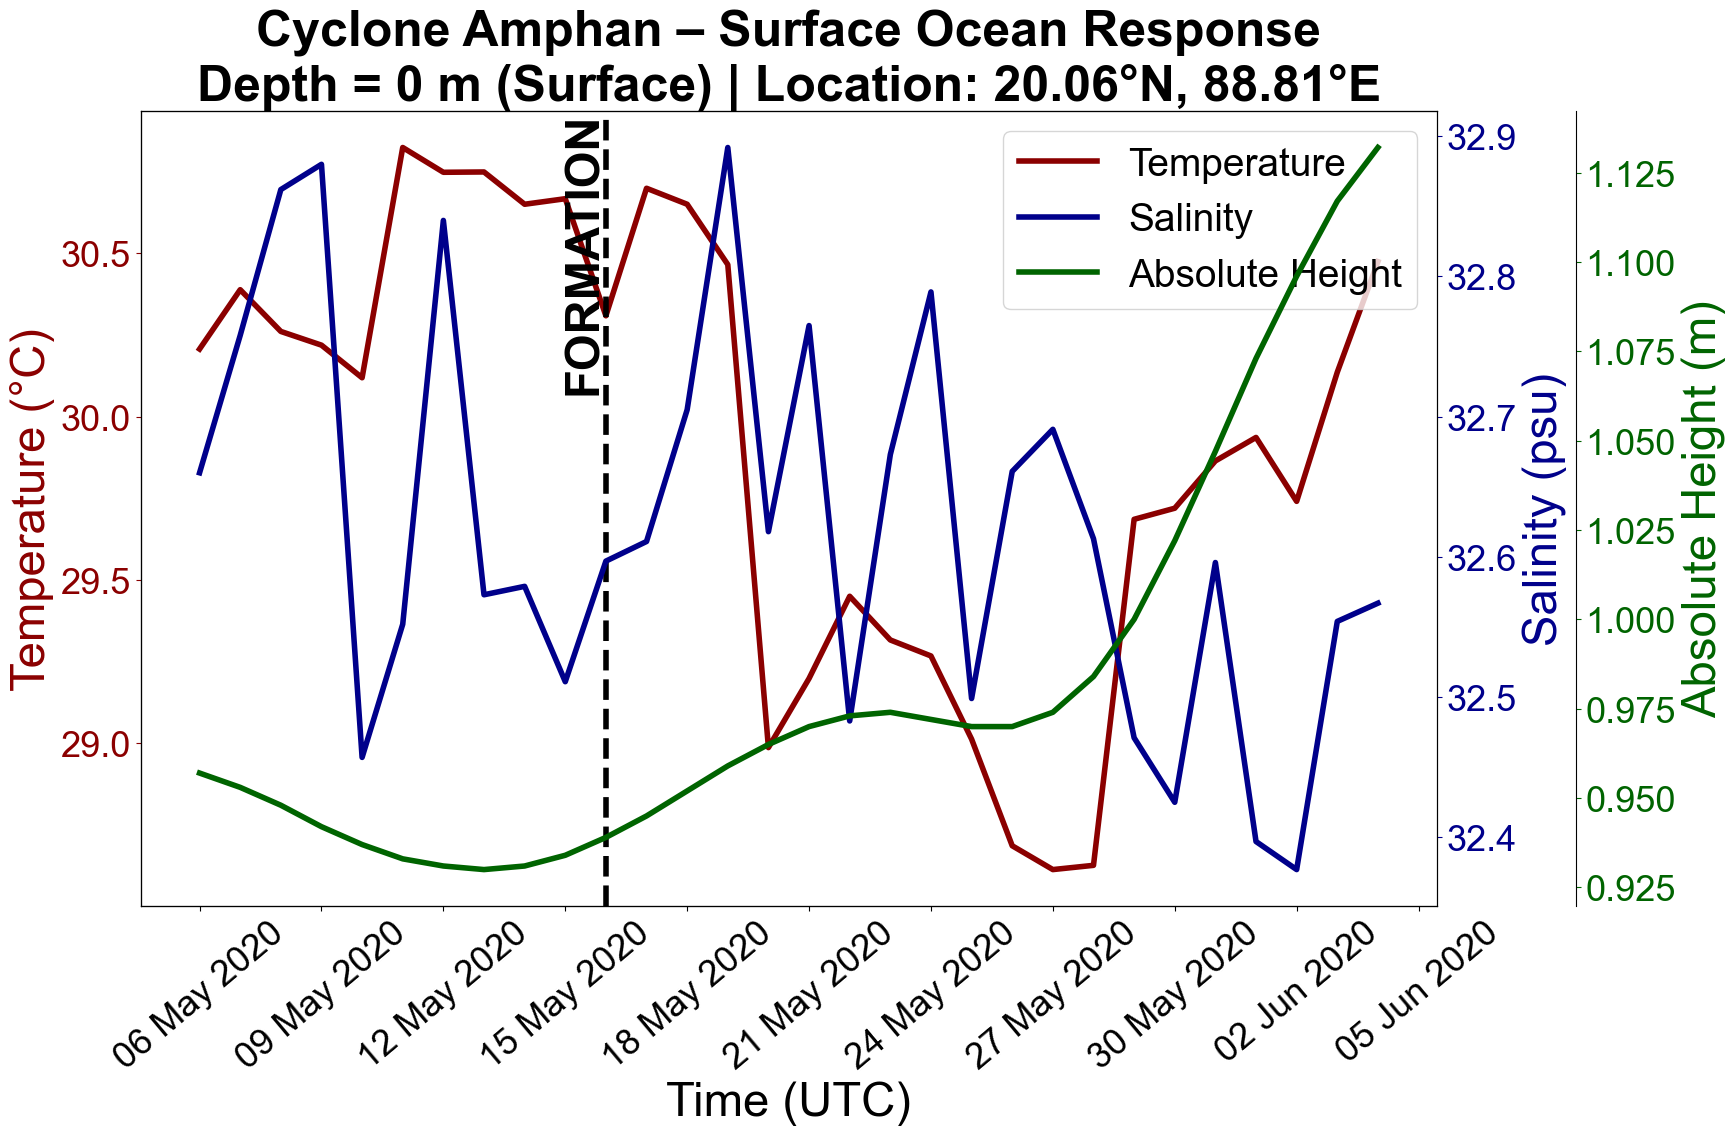

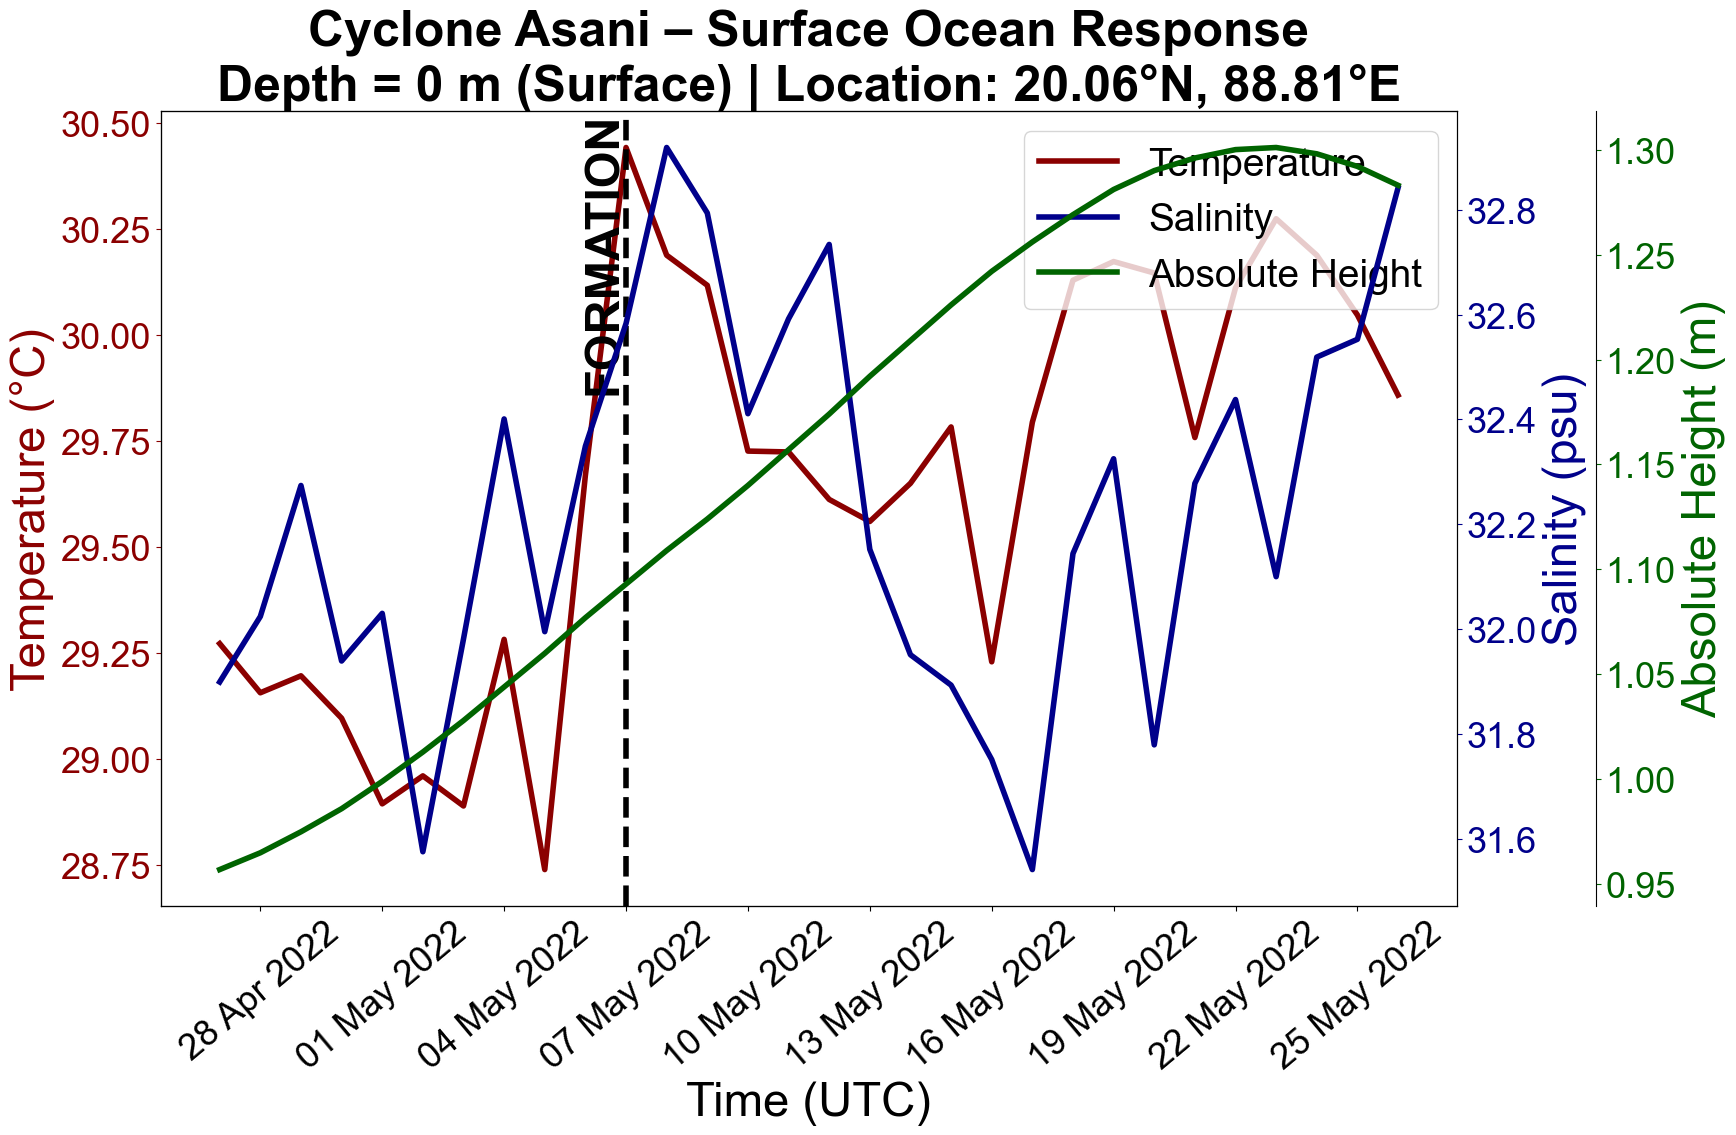

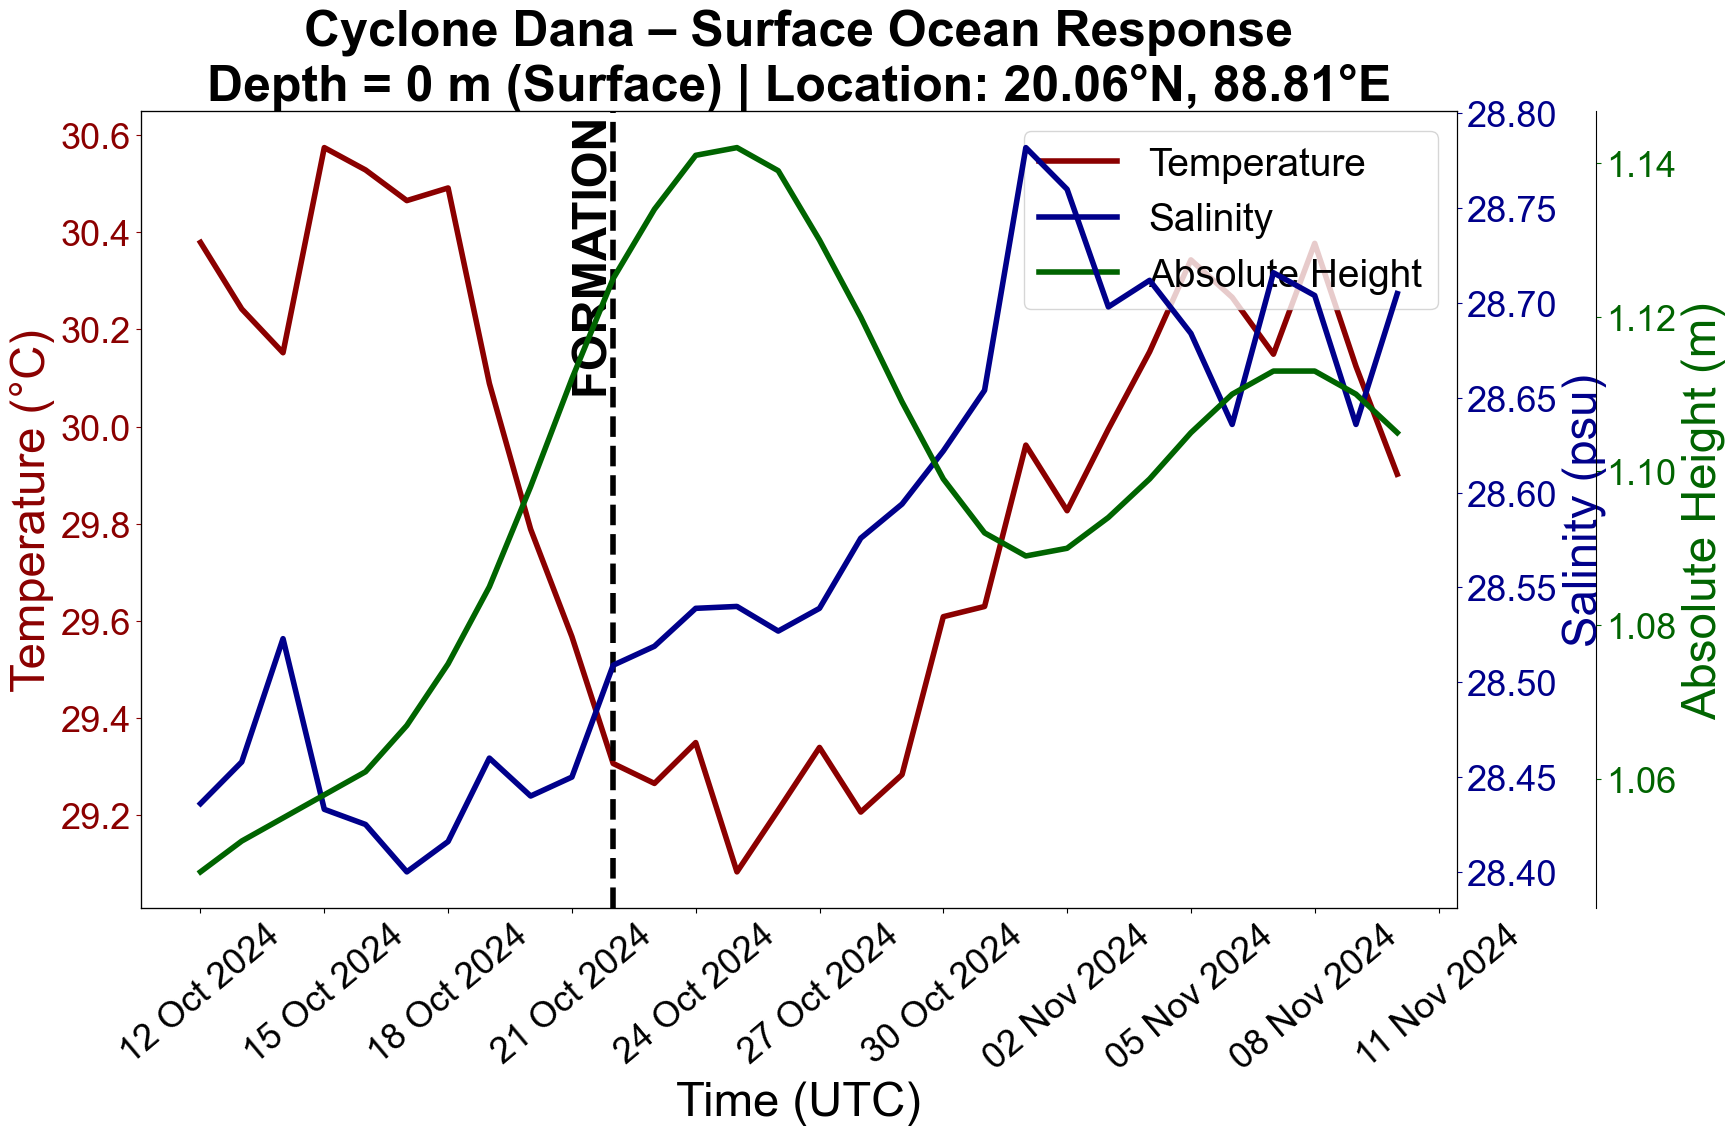

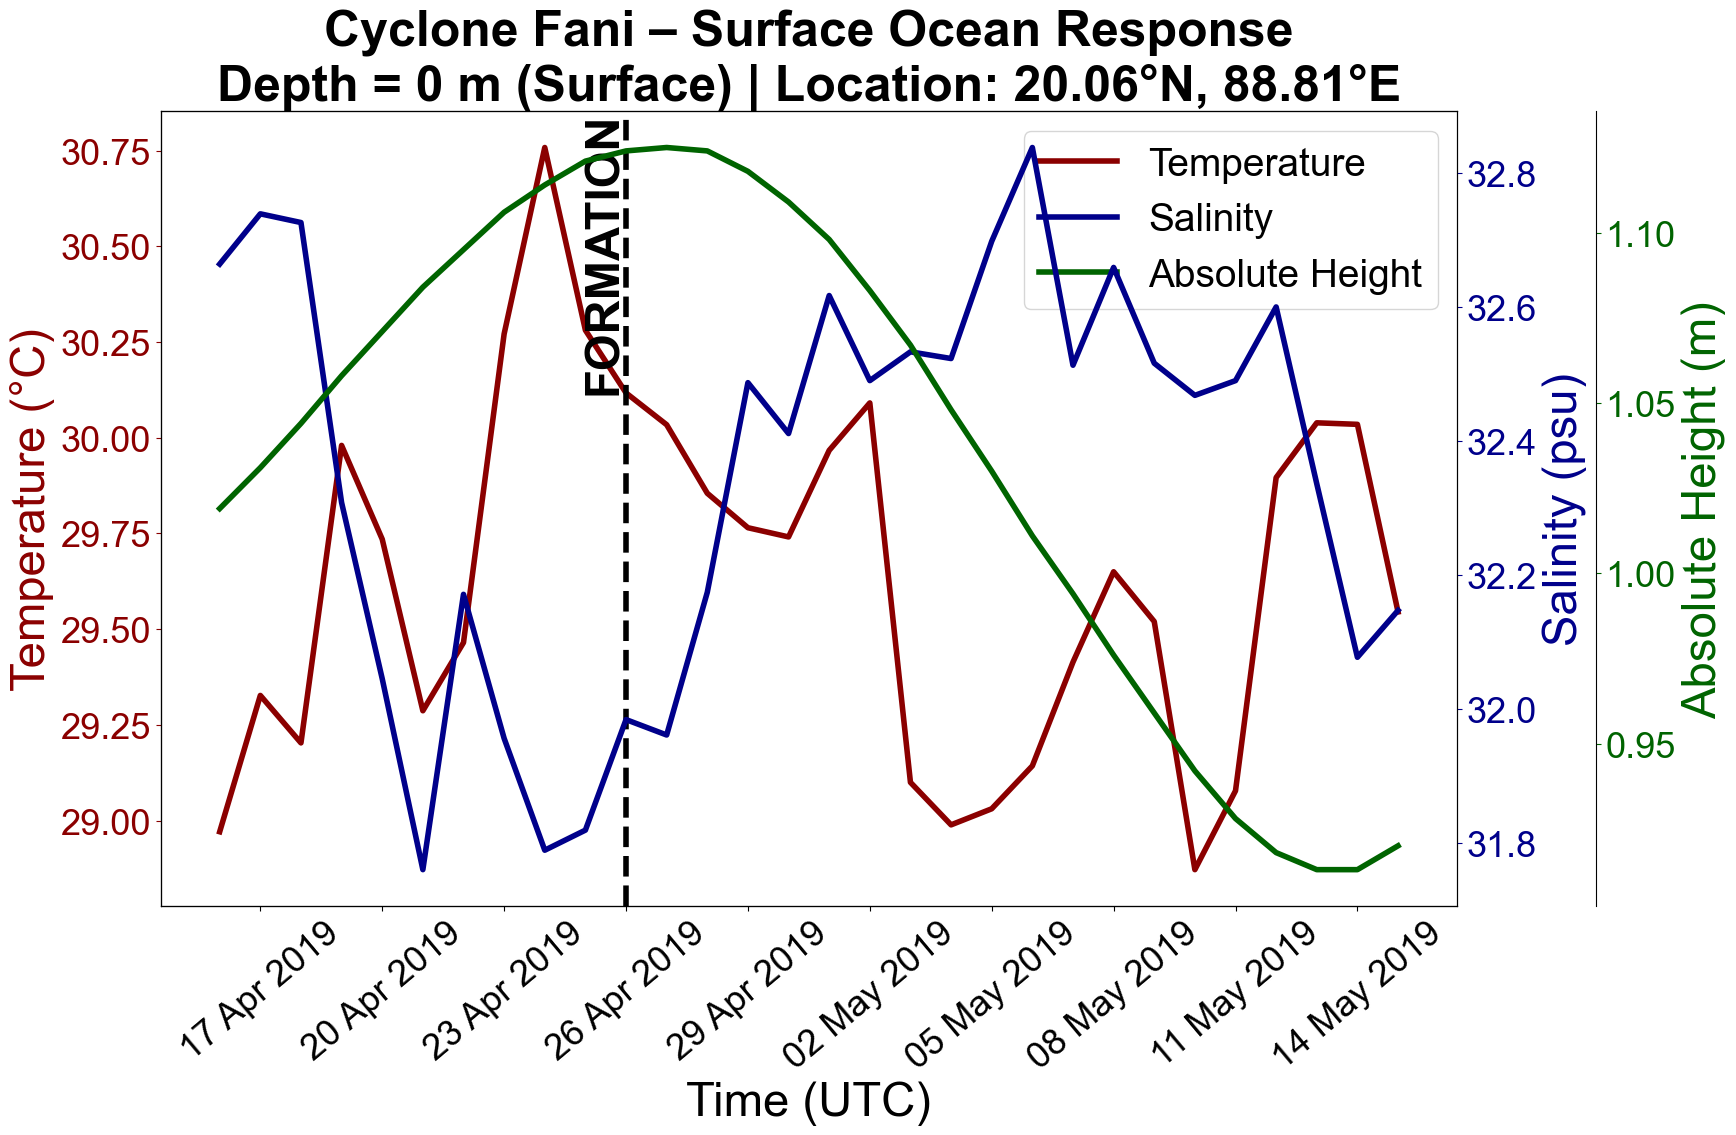

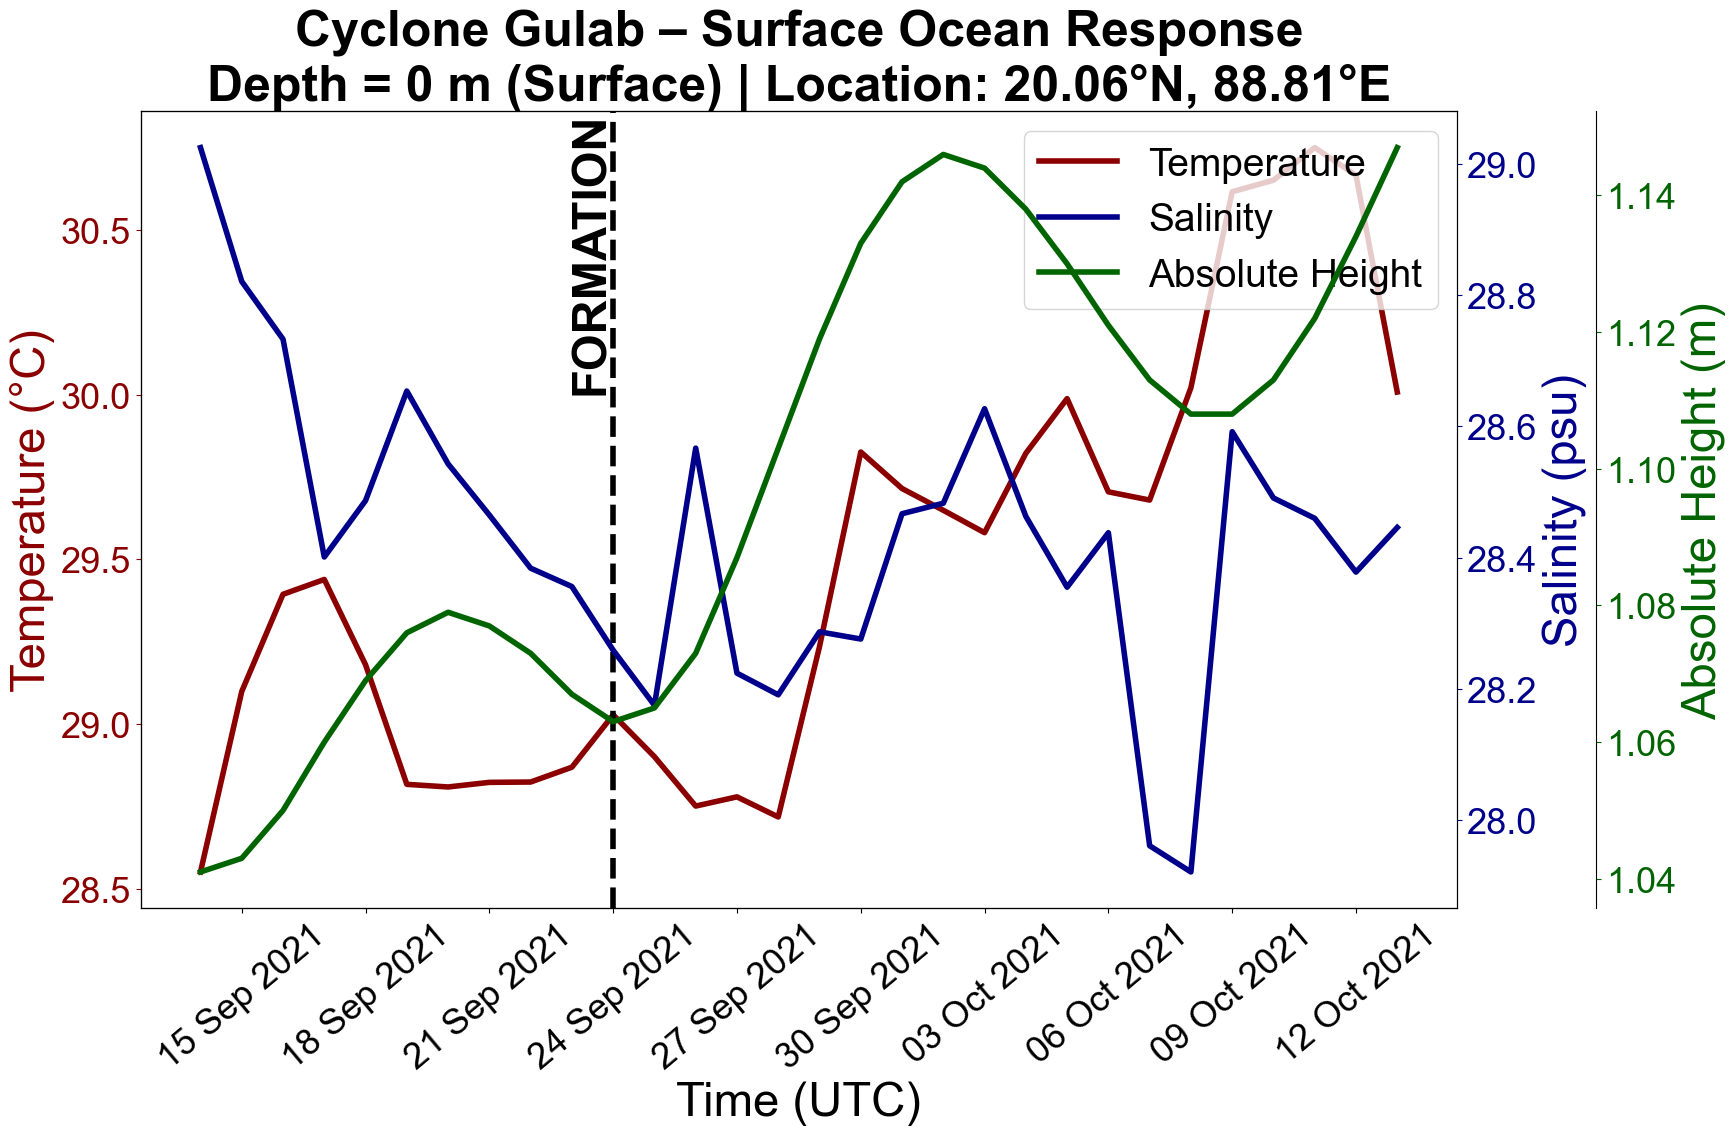

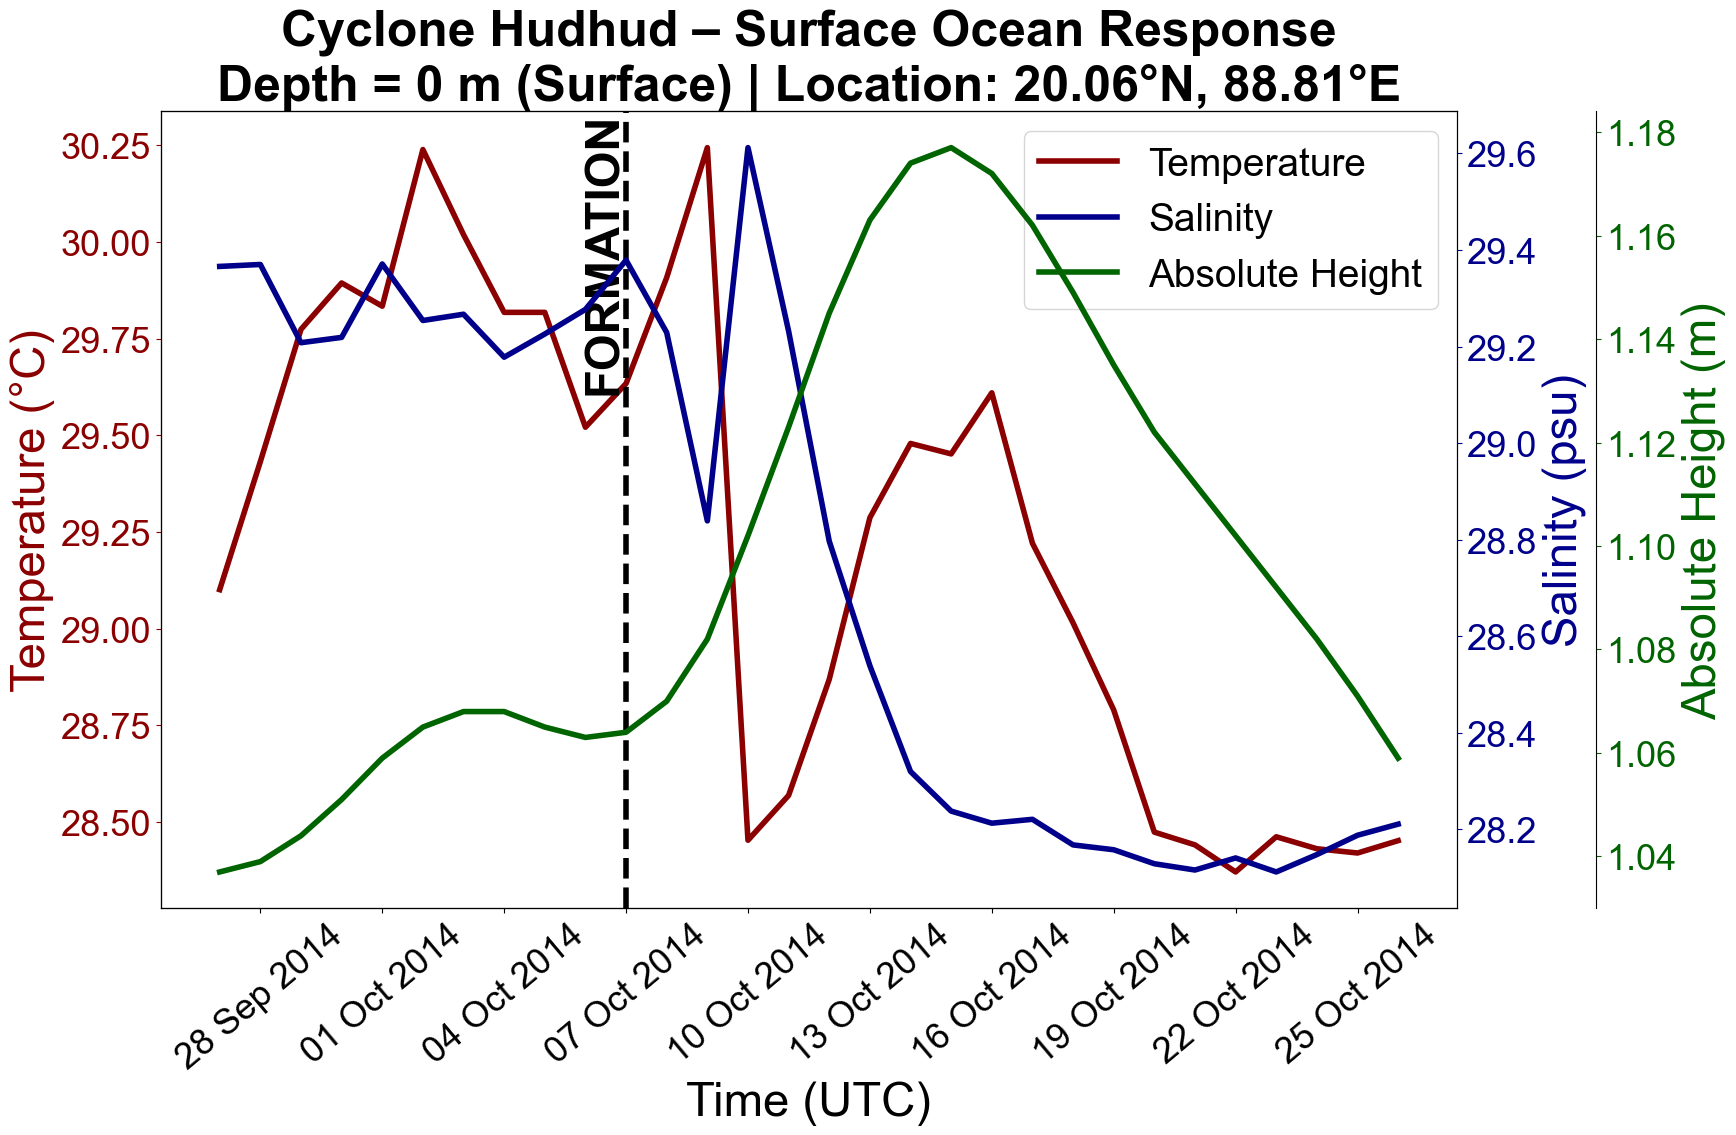

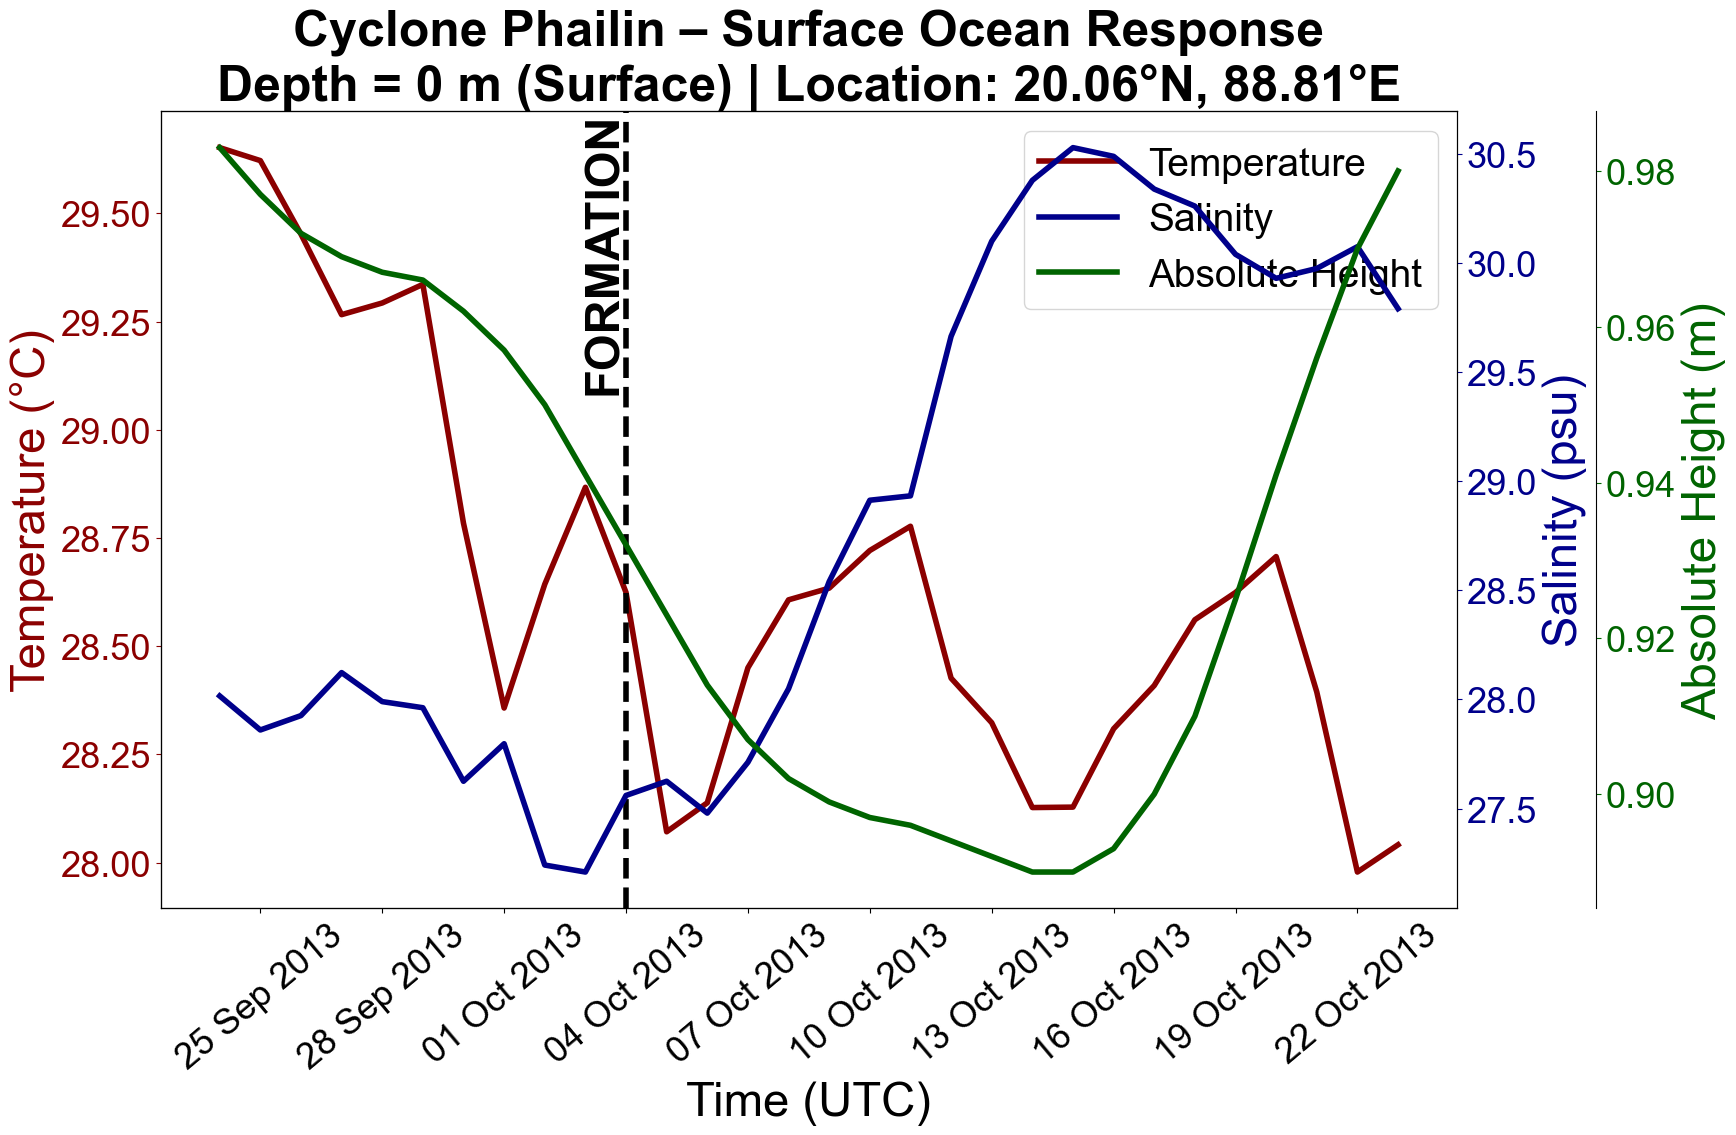

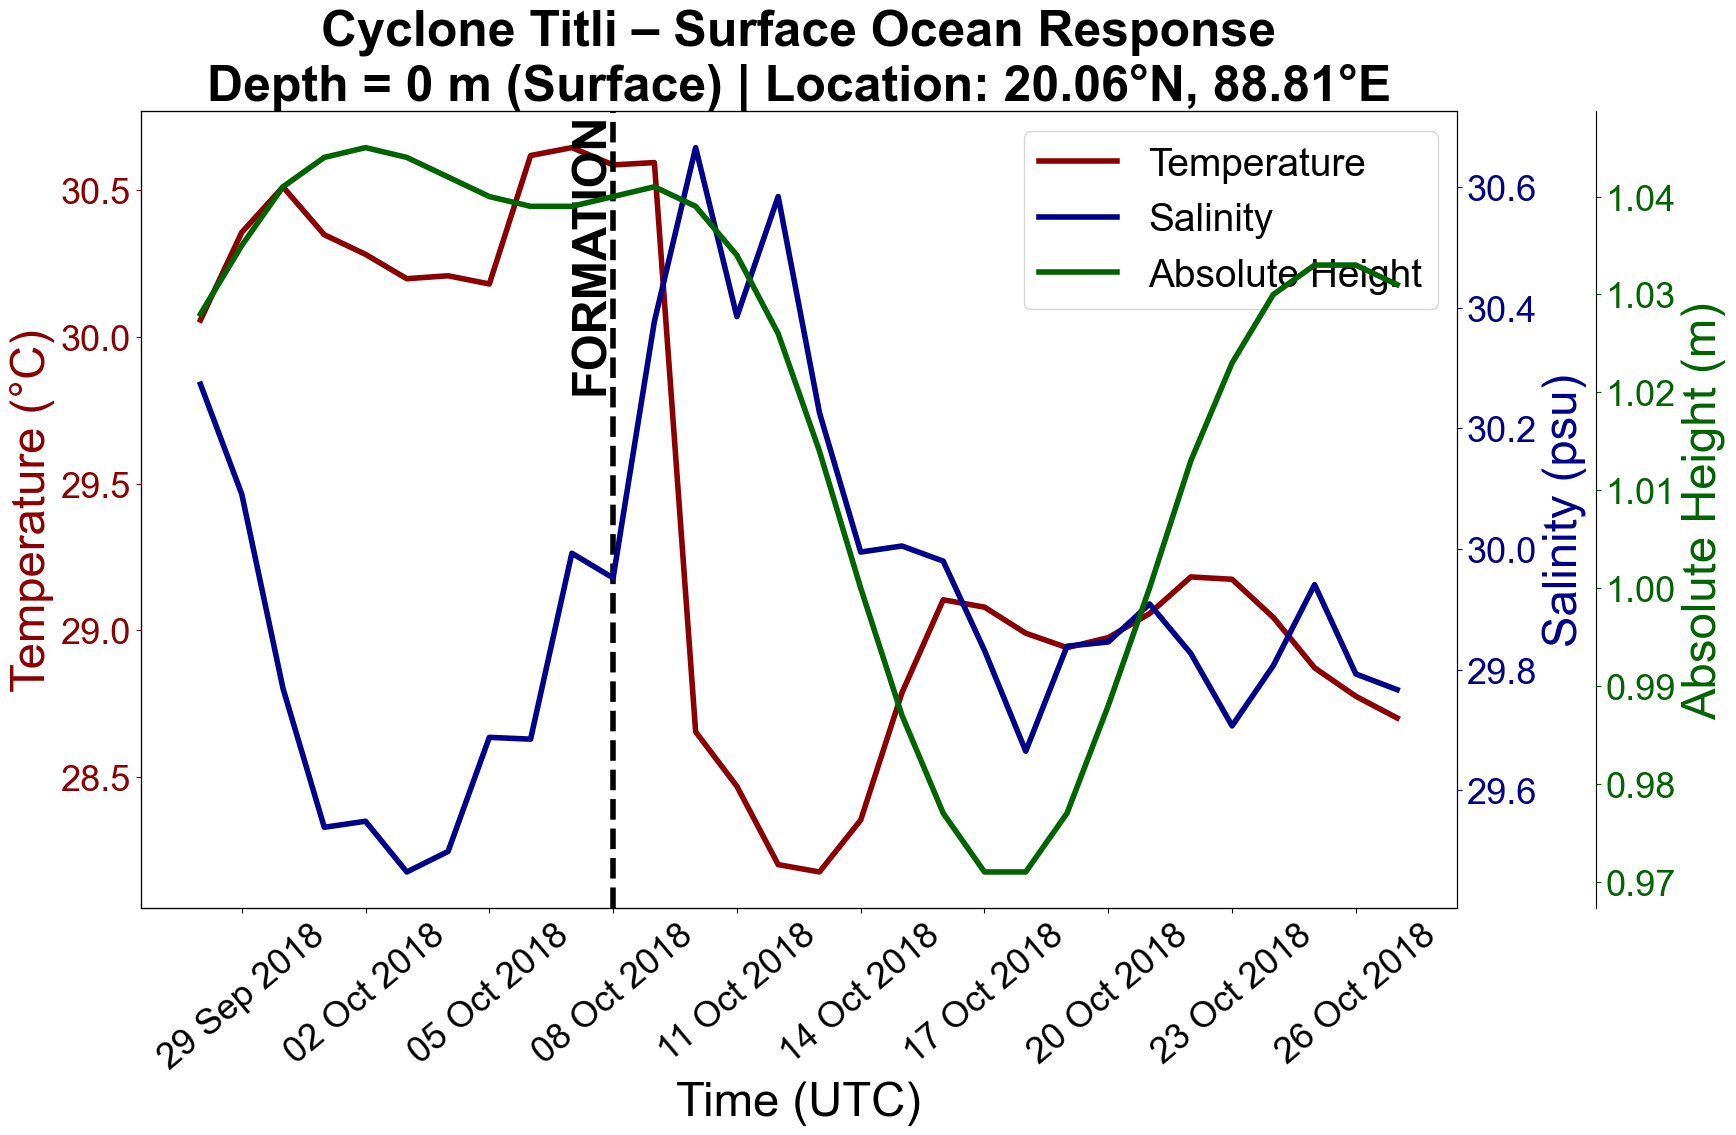

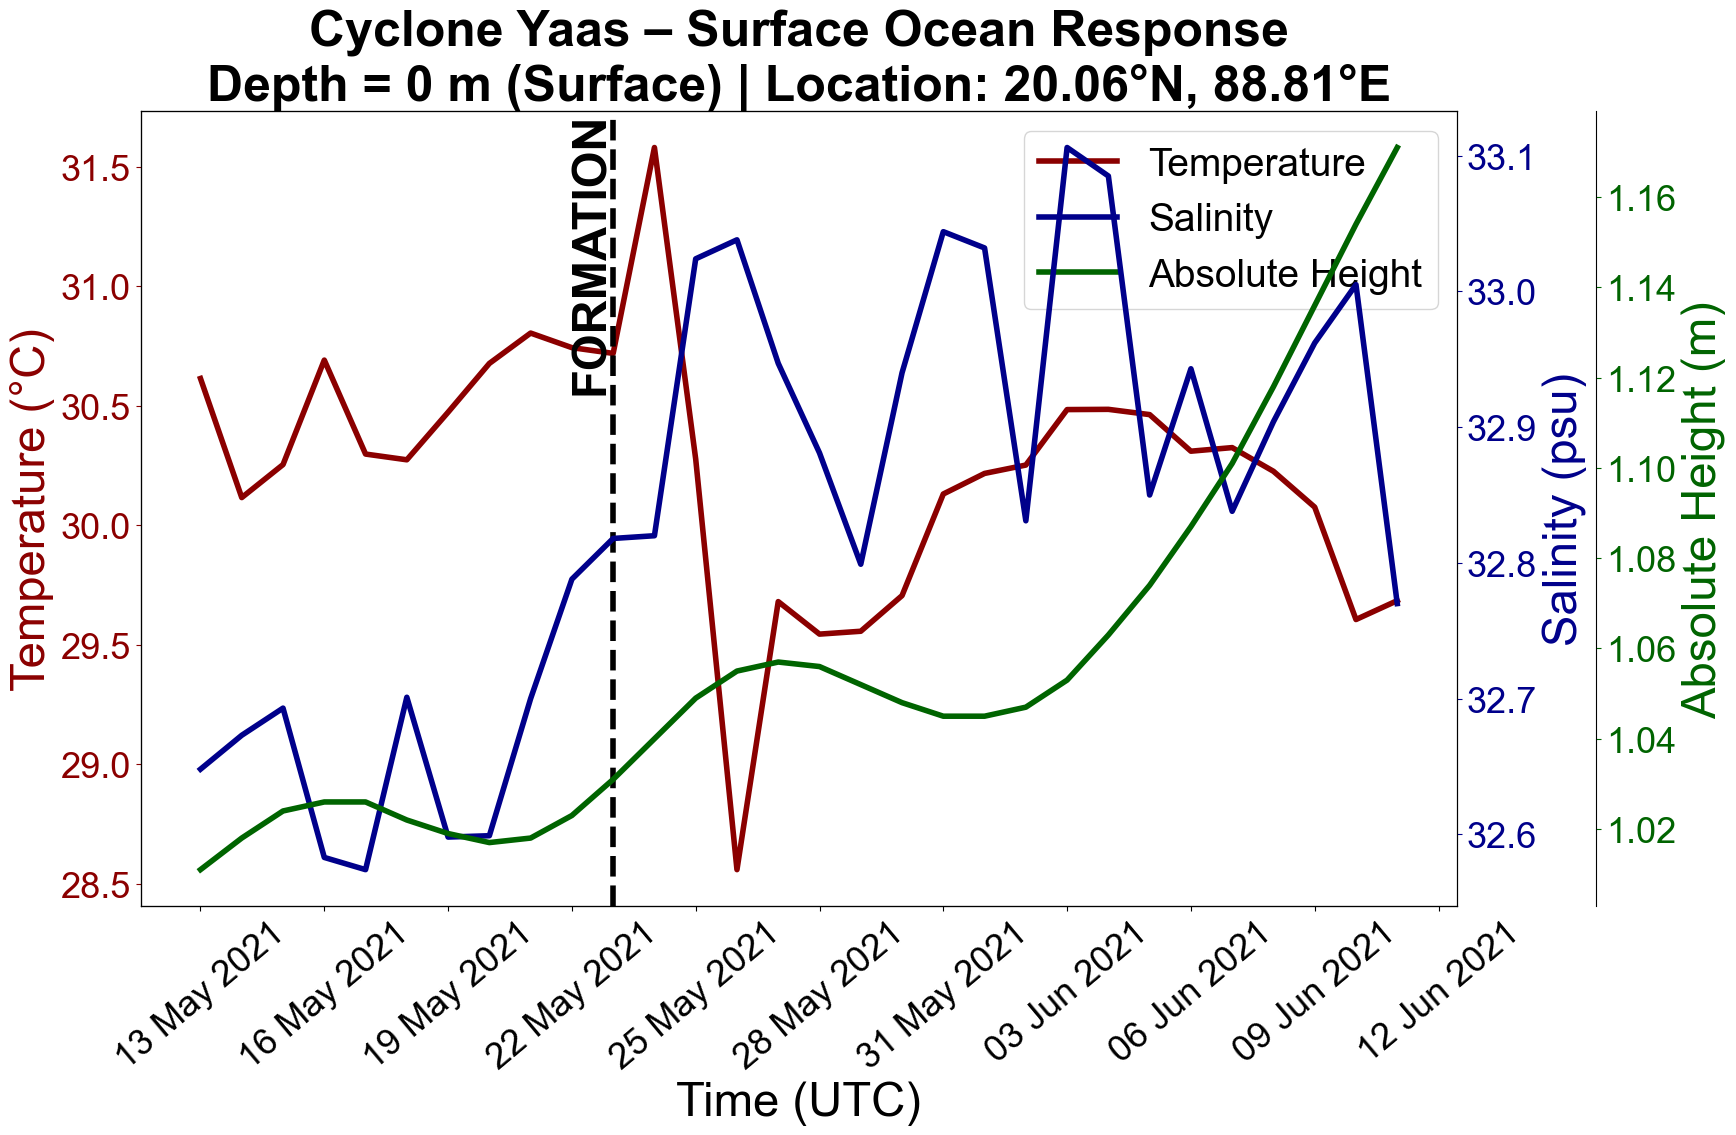

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 28,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 28
})

CYCLONES = ["Amphan","Asani","Dana","Fani",
            "Gulab","Hudhud","Phailin","Titli","Yaas"]

FORMATION_DATES = {
    "Phailin": "2013-10-04",
    "Hudhud": "2014-10-07",
    "Asani": "2022-05-07",
    "Titli": "2018-10-08",
    "Fani": "2019-04-26",
    "Amphan": "2020-05-16",
    "Yaas": "2021-05-23",
    "Dana": "2024-10-22",
    "Gulab": "2021-09-24"
}

LAT_INDEX = 40
LON_INDEX = 50

for i, ds in enumerate(datasets):

    cyclone_name = CYCLONES[i]

    temp = ds["to"].isel(depth=0, latitude=LAT_INDEX, longitude=LON_INDEX)
    sal  = ds["so"].isel(depth=0, latitude=LAT_INDEX, longitude=LON_INDEX)
    height = ds["zo"].isel(depth=0, latitude=LAT_INDEX, longitude=LON_INDEX)

    lat_value = float(ds.latitude[LAT_INDEX].values)
    lon_value = float(ds.longitude[LON_INDEX].values)

    time = temp.time.values
    formation_date = pd.to_datetime(FORMATION_DATES[cyclone_name])

    # ---------------- Figure ----------------
    fig, ax1 = plt.subplots(figsize=(18, 12))

    # Second and third y-axis
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()

    # Move third axis outward
    ax3.spines["right"].set_position(("outward", 100))

    # ---------------- Plot Lines ----------------
    line1 = ax1.plot(time, temp.values, color="darkred", linewidth=4, label="Temperature")
    line2 = ax2.plot(time, sal.values, color="darkblue", linewidth=4, label="Salinity")
    line3 = ax3.plot(time, height.values, color="darkgreen", linewidth=4, label="Absolute Height")

    # ---------------- Colored Y Labels ----------------
    ax1.set_ylabel("Temperature (°C)", color="darkred")
    ax2.set_ylabel("Salinity (psu)", color="darkblue")
    ax3.set_ylabel("Absolute Height (m)", color="darkgreen")

    ax1.tick_params(axis='y', colors="darkred")
    ax2.tick_params(axis='y', colors="darkblue")
    ax3.tick_params(axis='y', colors="darkgreen")

    # ---------------- Formation Line ----------------
    ax1.axvline(formation_date, color="black", linestyle="--", linewidth=4)

    ax1.text(
        formation_date,
        ax1.get_ylim()[1],
        "FORMATION",
        fontsize=34,
        fontweight='bold',
        rotation=90,
        verticalalignment='top',
        horizontalalignment='right'
    )

    # ---------------- X Axis ----------------
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax1.tick_params(axis='x', rotation=40)
    ax1.set_xlabel("Time (UTC)")

    # ---------------- Title ----------------
    plt.title(
        f"Cyclone {cyclone_name} – Surface Ocean Response\n"
        f"Depth = 0 m (Surface) | Location: {lat_value:.2f}°N, {lon_value:.2f}°E",
        fontsize=36,
        fontweight="bold"
    )

    # ---------------- Legend ----------------
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")

    # ---------------- Save ----------------
    plt.tight_layout()
    plt.savefig(f"{cyclone_name}_combined_poster.png", dpi=300, bbox_inches='tight')
    plt.show()


Surface Temperature Plot on 1st Day 


================ Cyclone 1 ================



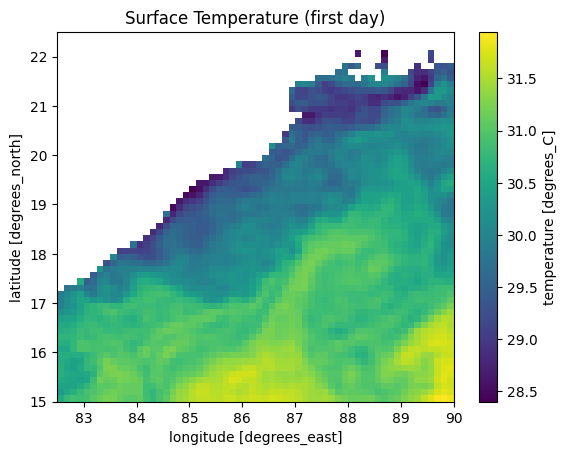


================ Cyclone 2 ================



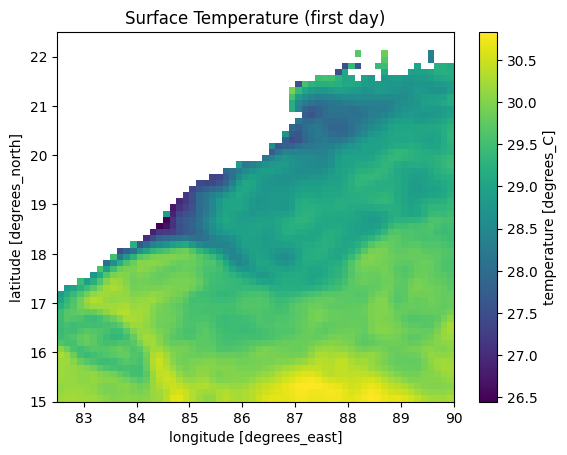


================ Cyclone 3 ================



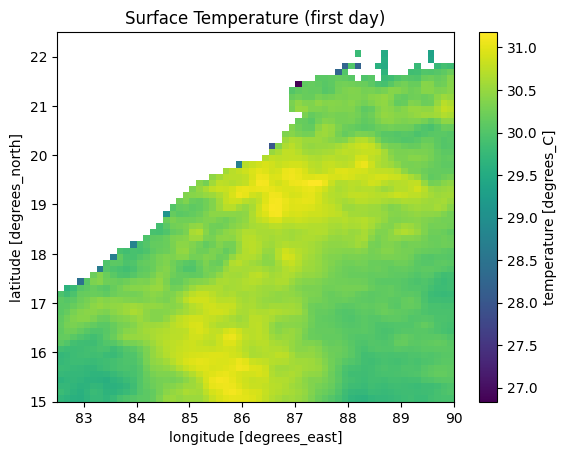


================ Cyclone 4 ================



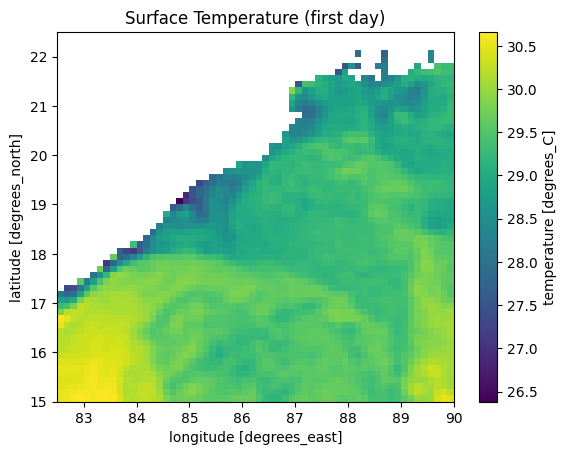


================ Cyclone 5 ================



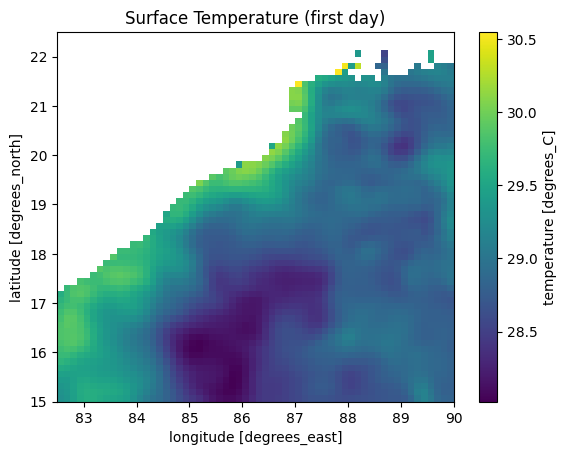


================ Cyclone 6 ================



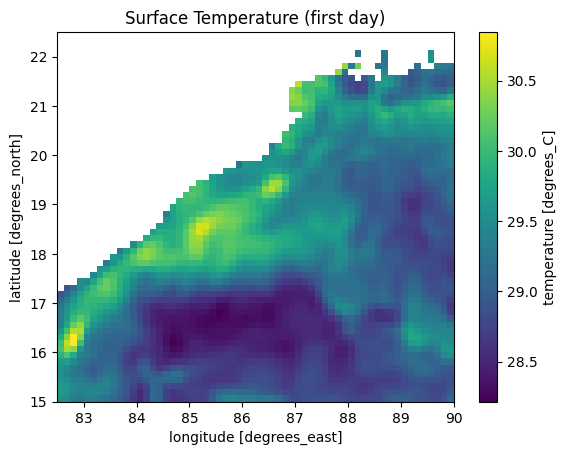


================ Cyclone 7 ================



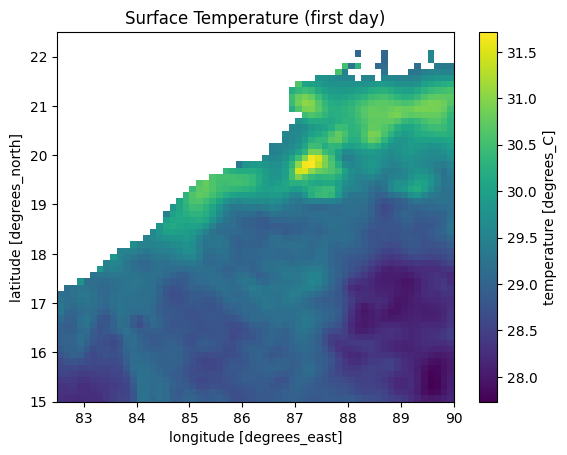


================ Cyclone 8 ================



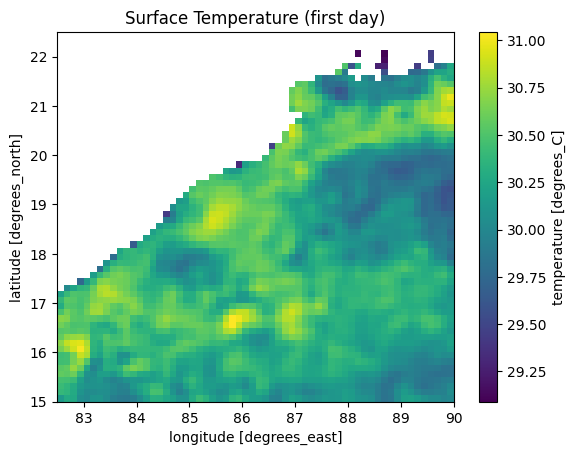


================ Cyclone 9 ================



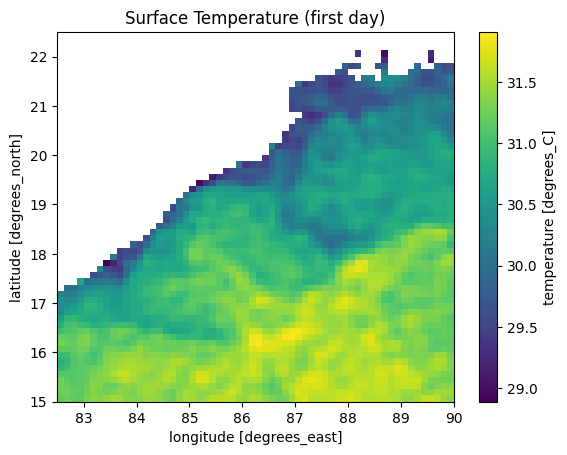

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CYCLONES = ["Amphan","Asani","Dana","Fani",
            "Gulab","Hudhud","Phailin","Titli","Yaas"]

for i, ds in enumerate(datasets):
    print(f"\n================ Cyclone {i+1} ================\n")
    
    #Visual sanity plot
    ds["to"].isel(time=0, depth=0).plot()
    plt.title("Surface Temperature (first day)")
    plt.show()